<a href="https://colab.research.google.com/github/RASIUT/ML/blob/main/Reinforcement_Learning/Thompson_Sampling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

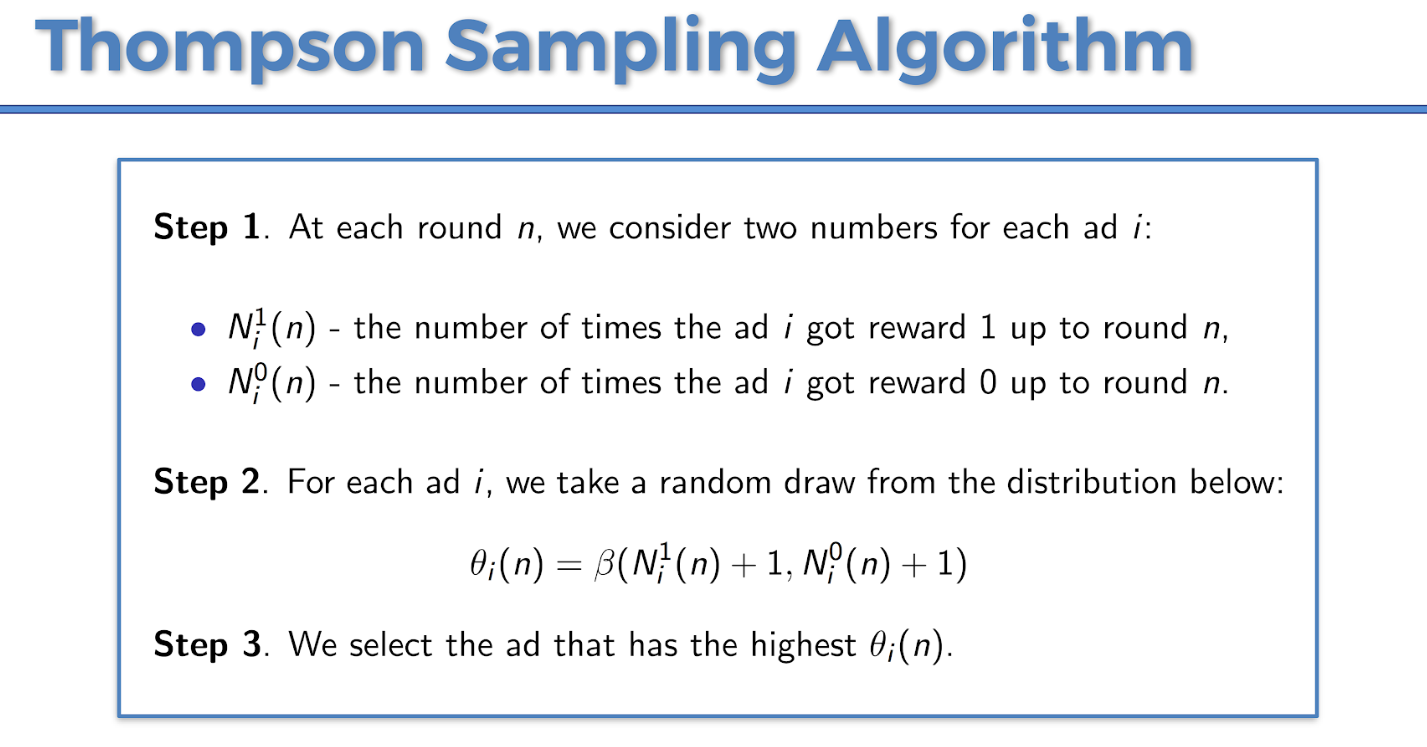

##Importing Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

##Importing datasets

In [2]:
df = pd.read_csv('/content/Ads_CTR_Optimisation.csv')

##Implementing Thompson Sampling

In [3]:
import random

In [4]:
N = len(df)
d = len(df.columns)
ads_selected = []

number_of_rewards_1 = [0] * d            # Number of times the ad i got reward 1 up to d rounds
number_of_rewards_0 = [0] * d            # Number of times the ad i got reward 0 up to d rounds

total_rewards = 0

for n in range(0, N):
  selected_ad = 0
  maximum_random = 0

  for i in range(0, d):
    random_beta = random.betavariate(number_of_rewards_1[i] + 1, number_of_rewards_0[i] + 1)             # Step 2: Calculate beta ( Ni_1(n) + 1, Ni_0(n) + 1 )

    if(random_beta > maximum_random):                                                                    # Step 3: Choose the ad with highest betavariate (Q_i)
      maximum_random = random_beta
      selected_ad = i

  ads_selected.append(selected_ad)
  reward = df.values[n, selected_ad]
  if(reward == 1):
    number_of_rewards_1[selected_ad] += 1
  else :
    number_of_rewards_0[selected_ad] += 1

  total_rewards = total_rewards + reward

##Visualize the Results

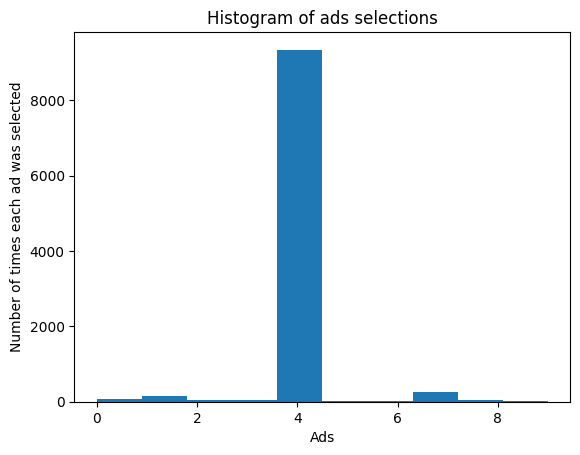

In [5]:
plt.hist(ads_selected)
plt.title('Histogram of ads selections')
plt.xlabel('Ads')
plt.ylabel('Number of times each ad was selected')
plt.show()